In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/train.txt', sep=';', header=None, names=['text', 'emotion'])
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [3]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

In [4]:
df['emotion'].value_counts()

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

In [5]:
unique_emotions = df['emotion'].unique()
emotion_numbers = {}
for i, emotion in enumerate(unique_emotions):
    emotion_numbers[emotion] = i
emotion_numbers

df['emotion'] = df['emotion'].map(emotion_numbers)

Text(0.5, 1.0, 'Distribution of Emotions in the Dataset')

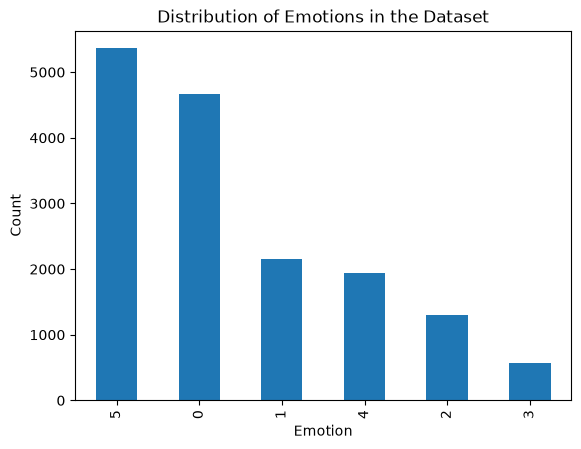

In [6]:
df['emotion'].value_counts().plot(kind='bar')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.title('Distribution of Emotions in the Dataset')

In [7]:
# 1. Convert into Lowercase
df['text'] = df['text'].apply(lambda x : x.lower())
df.head()

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,1
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,1


In [8]:
# Remove Punctuation
import string
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

In [9]:
df['text'] = df['text'].apply(remove_punctuation)

In [10]:
# Remove Number
def remove_number(text):
    new = ""
    for i in text:
      if not i.isdigit():
        new = new + i
    return new

df['text'] = df['text'].apply(remove_number)
df.head()

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,1
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,1


In [11]:
# Remove URL
import neattext.functions as nfx
df['text'] = df['text'].apply(nfx.remove_urls)
df.head()

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,1
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,1


In [12]:
# Remove emoji
import emoji

def remove_emoji(text):
    return emoji.replace_emoji(text, replace="")

df['text'] = df['text'].apply(remove_emoji)

In [13]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
nltk.download('stopwords')

# 1. Load stopwords and convert to a SET for faster processing
stop_words = set(stopwords.words('english'))

# 2. Create a function to process a single string
def remove_stopwords(text):
    words = word_tokenize(text)
    # Filter out stopwords
    filtered_words = [word for word in words if word.lower() not in stop_words]

    # Join the words back into a single string
    return " ".join(filtered_words)
df['text'] = df['text'].apply(remove_stopwords)

[nltk_data] Downloading package punkt_tab to C:\Users\Arin
[nltk_data]     Sharma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Arin
[nltk_data]     Sharma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
df.loc[1]['text']

'go feeling hopeless damned hopeful around someone cares awake'

In [15]:
df.head()

,text,emotion
0,didnt feel humiliated,0
1,go feeling hopeless damned hopeful around some...,0
2,im grabbing minute post feel greedy wrong,1
3,ever feeling nostalgic fireplace know still pr...,2
4,feeling grouchy,1


# Train Test Split

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['emotion'], test_size=0.2, random_state=42)


# Feature extraction

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [49]:
# Naive Bayes Classifier Model
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
pred_bow = nb_model.predict(X_test_bow)
print(accuracy_score(y_test, pred_bow))

0.7678125


In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=2)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Model Training & Evaluation

In [51]:
# Naive Bayes Classifier Model
nb2_model = MultinomialNB()
nb2_model.fit(X_train_tfidf,y_train)
y_pred = nb2_model.predict(X_test_tfidf)
print(accuracy_score(y_test, y_pred))

0.700625


In [52]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(class_weight='balanced', max_iter=1000)
logistic_model.fit(X_train_tfidf,y_train)
log_pred = logistic_model.predict(X_test_tfidf)
print(accuracy_score(y_test,log_pred ))

0.8990625


In [53]:
# SVM Classifier Model
from sklearn.svm import LinearSVC
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
print(accuracy_score(y_test, y_pred_svm))

0.9040625


# Hyperparameter Optimization

In [55]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

In [56]:
param_grid = {
    'C': [0.1, 0.5, 1, 2, 5]
}

In [57]:
grid = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [58]:
# Train
grid.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with higherv

In [59]:
# Best model
best_svm = grid.best_estimator_

In [60]:
# Prediction
y_pred = best_svm.predict(X_test_tfidf)

In [63]:
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'C': 1}
Best CV Accuracy: 0.9002343749999999
Test Accuracy: 0.9040625


## Save best model

In [64]:
import joblib
joblib.dump(best_svm, "../models/model.pkl")
joblib.dump(tfidf_vectorizer, "../models/vectorizer.pkl")

['../models/vectorizer.pkl']